In [40]:
from __future__ import annotations
import operator
from typing import TypedDict , List, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START,END
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

In [41]:
class Task(BaseModel):
    id : int
    title : str
    brief : str = Field(..., description="What to cover")

In [42]:
class Plan(BaseModel):
    blog_title : str
    tasks : List[Task]

In [61]:
class State(TypedDict):
    topic : str
    plan : Plan
    sections : Annotated[List[str], operator.add]
    final : str

In [62]:
llm = ChatOllama(model = 'llama3.1', temperature = 0.9)

In [32]:
import os

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0.7
)

In [20]:
llm.invoke("what is API").content

'API stands for **Application Programming Interface**.\n\nIn simple terms, an API is a set of rules and protocols that allows different software applications to communicate with each other. It acts as an **intermediary** that defines how software components should interact.\n\nThink of it like this:\n\n**The Waiter Analogy:**\n\n1.  **You (the "Client Application"):** You want to order food from a restaurant. You don\'t go into the kitchen to cook it yourself or tell the chef exactly how to prepare it.\n2.  **The Menu (the "API Documentation"):** This tells you what you can order (available functions/data) and how to order it (the specific requests you can make).\n3.  **The Waiter (the "API"):** You tell the waiter your order (make a "request"). The waiter takes your order to the kitchen.\n4.  **The Kitchen (the "Server/System"):** The kitchen prepares your food (processes the request).\n5.  **The Waiter (the "API"):** The waiter brings your food back to you (delivers the "response").\

In [63]:
def orchestrator(state : State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content = (
                    "Create a bolg plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content = f"Topic : {state['topic']}"),
        ]
    )

    return {"plan" : plan}

In [64]:
def fanout(state:State):
    return[Send("worker", {"task" : task, "topic" : state["topic"], "plan" : state["plan"]})
           for task in state["plan"].tasks]
    

In [65]:
def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]


    blog_title = plan.blog_title


    section_md = llm.invoke(
        [
        SystemMessage(content = "Write one clean Markdown section ."),
        HumanMessage(
            content = (
                f"Blog :{blog_title}\n"
                f"Topic:{topic}\n\n"
                f"Section ; {task.title}\n"
                f"Brief : {task.brief}\n\n"
                "Return only the section content in Markdown."
            )
        ),
        ]


    ).content.strip()
    return {"sections": [section_md]}



In [66]:
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"


    filename = title.lower().replace(" ","-") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding= "utf-8")
    return {"final": final_md}



In [67]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

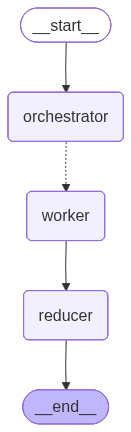

In [68]:
g.add_edge(START,"orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [71]:
out = app.invoke({"topic" : "Write a blog on multi agent system "})

In [72]:
print(out["final"])

# Understanding and Implementing Multi-Agent Systems

**Introduction to Multi-Agent Systems**

A Multi-Agent System (MAS) is a computational system composed of multiple interacting agents. These agents can be thought of as autonomous entities that are capable of making decisions, taking actions, and communicating with each other. Each agent has its own goals, needs, and knowledge, which it uses to reason about the world and make decisions.

### Importance of Multi-Agent Systems

Multi-agent systems are gaining popularity due to their ability to model complex real-world phenomena in a scalable way. They have numerous applications across various fields, including:

*   Autonomous robotics
*   Intelligent transportation systems
*   Finance and economics
*   Social network analysis
*   Healthcare and medicine

## Architecture of a Multi-Agent System

A Multi-Agent System (MAS) is composed of three primary components: Agents, Environment, and Interactions.

### 1. **Agents**

*   A software